## 1. 라이브러리 및 환경 설정

In [8]:
import os
import sys
import json
import random
import pandas as pd
import numpy as np
import cv2
import shutil
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import timm

from pathlib import Path

SRC_DIR = (Path.cwd() / '../src').resolve()
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from augmentations import build_default_transforms
from output_paths import allocate_output_paths
from reproducibility import make_generator, seed_everything, seed_worker

# /src 에서 실행하는 기준 경로 설정
DATA_DIR = (Path.cwd() / '../data').resolve()
assert DATA_DIR.exists(), f"data 폴더를 찾지 못했습니다: {DATA_DIR}"
print(f"DATA_DIR: {DATA_DIR}")

# 하이퍼파라미터 설정
CFG = {
    'IMG_SIZE': 320,
    'EPOCHS': 100,
    'LEARNING_RATE': 3e-4,
    'BATCH_SIZE': 32,
    'SEED': 42,
    'NUM_WORKERS': 16,
    'WEIGHT_DECAY': 1e-4,  # L2 regularization
    'MIXUP_ALPHA': 0.1,
    'MIXUP_PROB': 0,
    'MIN_LR': 1e-6,
    'EMA_DECAY': 0.999,
    'EMA_USE_FOR_EVAL': True,
    'TTA_CANDIDATES': [
        ['none'],
        ['none', 'hflip'],
        ['none', 'hflip', 'crop95'],
    ],
    # video frame augmentation (for unstable videos)
    'VIDEO_AUG_ENABLE': True,
    'VIDEO_AUG_CACHE': True,
    'UNSTABLE_START_MIN_SEC': 0.5,
    'UNSTABLE_START_MAX_SEC': 1.0,
    'UNSTABLE_FRAMES_MIN': 2,
    'UNSTABLE_FRAMES_MAX': 3,
    'STABLE_END_MIN_SEC': 9.0,
    'STABLE_END_MAX_SEC': 10.0,
    'STABLE_FRAMES_PER_VIDEO': 2
}


seed_everything(CFG['SEED'])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


DATA_DIR: /media/hdd0/whyz/structure-stability/data


## 2. 데이터 로드 및 학습/검증 데이터 분할

In [9]:
# 1. 데이터 로드
train_df = pd.read_csv(DATA_DIR / 'train.csv', encoding='utf-8-sig')
val_df = pd.read_csv(DATA_DIR / 'dev.csv', encoding='utf-8-sig')

print(f"학습 데이터 개수: {len(train_df)}")
print(f"검증 데이터 개수: {len(val_df)}")

학습 데이터 개수: 1000
검증 데이터 개수: 100


## 3. 커스텀 데이터셋 클래스 정의 및 데이터 로더

In [10]:
class MultiViewDataset(Dataset):
    def __init__(self, df, root_dir, transform=None, is_test=False):
        self.df = df.reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform
        self.is_test = is_test
        self.label_map = {'stable': 0, 'unstable': 1}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        sample_id = str(row['id'])

        base_dir = self.root_dir
        if ('sample_dir' in self.df.columns) and pd.notna(row.get('sample_dir', np.nan)):
            base_dir = str(row['sample_dir'])

        folder_path = os.path.join(base_dir, sample_id)

        views = []
        for name in ['front', 'top']:
            img_path = os.path.join(folder_path, f'{name}.png')
            image = Image.open(img_path).convert('RGB')
            if self.transform:
                image = self.transform(image)
            views.append(image)

        if self.is_test:
            return views

        label = self.label_map[row['label']]
        return views, label



In [11]:

def _extract_frame_by_sec(cap, sec, fps, frame_count):
    frame_idx = int(max(0, min(frame_count - 1, round(sec * fps))))
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ok, frame = cap.read()
    if not ok:
        return None
    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)


def _extract_last_frame(cap, frame_count):
    last_idx = max(0, frame_count - 1)
    cap.set(cv2.CAP_PROP_POS_FRAMES, last_idx)
    ok, frame = cap.read()
    if not ok:
        return None
    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)


def _video_aug_cache_signature(cfg):
    keys = [
        'SEED',
        'UNSTABLE_START_MIN_SEC',
        'UNSTABLE_START_MAX_SEC',
        'UNSTABLE_FRAMES_MIN',
        'UNSTABLE_FRAMES_MAX',
        'STABLE_END_MIN_SEC',
        'STABLE_END_MAX_SEC',
        'STABLE_FRAMES_PER_VIDEO',
    ]
    return {k: cfg.get(k) for k in keys}


def build_video_augmented_df(train_df, data_dir, cfg):
    train_root = data_dir / 'train'
    aug_root = data_dir / 'train_video_aug'
    aug_root.mkdir(parents=True, exist_ok=True)

    cache_csv = aug_root / 'aug_df.csv'
    cache_meta = aug_root / 'cache_meta.json'
    cache_sig = _video_aug_cache_signature(cfg)

    if cfg.get('VIDEO_AUG_CACHE', True) and cache_csv.exists() and cache_meta.exists():
        try:
            meta = json.loads(cache_meta.read_text())
            if meta.get('signature') == cache_sig:
                cached_df = pd.read_csv(cache_csv)
                if not cached_df.empty:
                    cached_df['sample_dir'] = str(aug_root)
                    print(f'video aug cache hit: {len(cached_df)} samples from {cache_csv}')
                    return cached_df
        except Exception as e:
            print(f'video aug cache read failed. rebuild cache. ({e})')

    # 캐시 미스 시 기존 AUGV_* 폴더만 정리 후 재생성
    for p in aug_root.glob('AUGV_*'):
        if p.is_dir():
            shutil.rmtree(p, ignore_errors=True)

    rng = np.random.default_rng(cfg['SEED'])
    stable_rows = []
    unstable_rows = []
    saved_idx = 0

    def save_aug(img, label):
        nonlocal saved_idx
        aug_id = f'AUGV_{saved_idx:07d}'
        out_dir = aug_root / aug_id
        out_dir.mkdir(parents=True, exist_ok=True)
        Image.fromarray(img).save(out_dir / 'front.png')
        Image.fromarray(img).save(out_dir / 'top.png')
        row = {'id': aug_id, 'label': label, 'sample_dir': str(aug_root)}
        saved_idx += 1
        return row

    # 1) stable 증강: stable/unstable 모든 영상의 마지막 프레임 1장씩 사용
    all_ids = train_df['id'].tolist()
    for sample_id in tqdm(all_ids, desc='Video aug stable(last-frame)', dynamic_ncols=True, ascii=True):
        video_path = train_root / sample_id / 'simulation.mp4'
        if not video_path.exists():
            continue

        cap = cv2.VideoCapture(str(video_path))
        if not cap.isOpened():
            cap.release()
            continue

        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if frame_count <= 0:
            cap.release()
            continue

        img = _extract_last_frame(cap, frame_count)
        cap.release()
        if img is None:
            continue

        stable_rows.append(save_aug(img, 'stable'))

    # 2) unstable 증강: unstable 영상의 0.5~1.0초 구간에서 2~3장 샘플링
    unstable_ids = train_df.loc[train_df['label'] == 'unstable', 'id'].tolist()
    for sample_id in tqdm(unstable_ids, desc='Video aug unstable(0.5~1.0s)', dynamic_ncols=True, ascii=True):
        video_path = train_root / sample_id / 'simulation.mp4'
        if not video_path.exists():
            continue

        cap = cv2.VideoCapture(str(video_path))
        if not cap.isOpened():
            cap.release()
            continue

        fps = cap.get(cv2.CAP_PROP_FPS)
        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if fps is None or fps <= 0 or frame_count <= 1:
            cap.release()
            continue

        duration = frame_count / fps
        low = cfg['UNSTABLE_START_MIN_SEC']
        high = min(cfg['UNSTABLE_START_MAX_SEC'], max(0.0, duration - 1.0 / fps))
        if high <= low:
            cap.release()
            continue

        n_unstable = int(rng.integers(cfg['UNSTABLE_FRAMES_MIN'], cfg['UNSTABLE_FRAMES_MAX'] + 1))
        unstable_secs = rng.uniform(low, high, size=n_unstable)

        for sec in unstable_secs:
            img = _extract_frame_by_sec(cap, float(sec), fps, frame_count)
            if img is None:
                continue
            unstable_rows.append(save_aug(img, 'unstable'))

        cap.release()

    stable_df = pd.DataFrame(stable_rows)
    unstable_df = pd.DataFrame(unstable_rows)

    if stable_df.empty or unstable_df.empty:
        print('video aug warning: stable/unstable 중 하나가 비어 비율 매칭 불가')
        return pd.DataFrame(columns=['id', 'label', 'sample_dir'])

    # 3) stable 개수에 맞춰 unstable 개수 정렬
    target_unstable = len(stable_df)
    if len(unstable_df) >= target_unstable:
        unstable_bal = unstable_df.sample(n=target_unstable, random_state=cfg['SEED'])
    else:
        unstable_bal = unstable_df.sample(n=target_unstable, replace=True, random_state=cfg['SEED'])

    aug_df = pd.concat([stable_df, unstable_bal], ignore_index=True)
    aug_df = aug_df.sample(frac=1.0, random_state=cfg['SEED']).reset_index(drop=True)

    # 캐시 저장
    if cfg.get('VIDEO_AUG_CACHE', True):
        aug_df.to_csv(cache_csv, index=False)
        cache_meta.write_text(json.dumps({'signature': cache_sig}, ensure_ascii=False, indent=2))
        print(f'video aug cache saved: {cache_csv}')

    print(f'video aug stable(last-frame): {len(stable_df)}')
    print(f'video aug unstable(sampled): {len(unstable_bal)}')
    return aug_df


train_transform, test_transform = build_default_transforms(CFG['IMG_SIZE'])
])

# 원본 학습 데이터(기본 1:1)
train_df_for_train = train_df.copy()
train_df_for_train['sample_dir'] = str(DATA_DIR / 'train')

# 비디오 프레임 기반 증강 데이터 생성
if CFG.get('VIDEO_AUG_ENABLE', False):
    aug_df = build_video_augmented_df(train_df, DATA_DIR, CFG)
    if len(aug_df) > 0:
        train_df_for_train = pd.concat([train_df_for_train, aug_df], ignore_index=True)
        print(f'video aug added: {len(aug_df)} samples')
    else:
        print('video aug added: 0 samples (check video availability)')

# 최종 학습 비율 확인
print('Final train class ratio:')
print(train_df_for_train['label'].value_counts())

val_df_for_eval = val_df.copy()
val_df_for_eval['sample_dir'] = str(DATA_DIR / 'dev')

# 1. 학습/검증 세트 준비
train_dataset = MultiViewDataset(train_df_for_train, str(DATA_DIR / 'train'), train_transform, is_test=False)
val_dataset = MultiViewDataset(val_df_for_eval, str(DATA_DIR / 'dev'), test_transform, is_test=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=CFG['BATCH_SIZE'],
    shuffle=True,
    num_workers=CFG['NUM_WORKERS'],
    pin_memory=(device.type == 'cuda'),
    worker_init_fn=seed_worker,
    generator=make_generator(CFG['SEED'])
)
val_loader = DataLoader(
    val_dataset,
    batch_size=CFG['BATCH_SIZE'],
    shuffle=False,
    num_workers=CFG['NUM_WORKERS'],
    pin_memory=(device.type == 'cuda'),
    worker_init_fn=seed_worker,
    generator=make_generator(CFG['SEED'] + 1)
)

# 2. 테스트 세트 준비
test_df = pd.read_csv(DATA_DIR / 'sample_submission.csv', encoding='utf-8-sig')
test_df_for_infer = test_df.copy()
test_df_for_infer['sample_dir'] = str(DATA_DIR / 'test')

test_dataset = MultiViewDataset(test_df_for_infer, str(DATA_DIR / 'test'), test_transform, is_test=True)
test_loader = DataLoader(
    test_dataset,
    batch_size=CFG['BATCH_SIZE'],
    shuffle=False,
    num_workers=CFG['NUM_WORKERS'],
    pin_memory=(device.type == 'cuda'),
    worker_init_fn=seed_worker,
    generator=make_generator(CFG['SEED'] + 2)
)


video aug cache hit: 2000 samples from /media/hdd0/whyz/structure-stability/data/train_video_aug/aug_df.csv
video aug added: 2000 samples
Final train class ratio:
label
unstable    1500
stable      1500
Name: count, dtype: int64


## 4. 모델 정의 (Multi-View )

In [12]:
from models import (
    EMAConfig,
    ModelEMA,
    MultiViewFeatureFusion,
    MultiViewFeatureFusionConfig,
)

MODEL_CONFIG = MultiViewFeatureFusionConfig()
EMA_CONFIG = EMAConfig(decay=CFG['EMA_DECAY'])


## 4. 학습 및 검증 루프 구현

In [13]:
def mixup_multiview_batch(views, labels, alpha=0.2):
    """Apply mixup to multi-view inputs with the same permutation/lambda across all views."""
    if alpha <= 0:
        return views, labels, labels, 1.0

    lam = np.random.beta(alpha, alpha)
    batch_size = labels.size(0)
    index = torch.randperm(batch_size, device=labels.device)

    mixed_views = [lam * v + (1.0 - lam) * v[index, :] for v in views]
    labels_a = labels
    labels_b = labels[index]
    return mixed_views, labels_a, labels_b, lam


def train_one_epoch(model, loader, criterion, optimizer, device, mixup_alpha=0.2, mixup_prob=0.5, ema=None):
    model.train()
    train_loss = 0
    for views, labels in tqdm(loader, desc="Training", dynamic_ncols=True, ascii=True):
        views = [v.to(device) for v in views]
        labels = labels.to(device).float()

        optimizer.zero_grad()

        if mixup_alpha > 0 and np.random.rand() < mixup_prob:
            mixed_views, labels_a, labels_b, lam = mixup_multiview_batch(views, labels, alpha=mixup_alpha)
            outputs = model(mixed_views).view(-1)
            loss = lam * criterion(outputs, labels_a) + (1.0 - lam) * criterion(outputs, labels_b)
        else:
            outputs = model(views).view(-1)
            loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()
        if ema is not None:
            ema.update(model)

        train_loss += loss.item()
    return train_loss / len(loader)


def validate(model, loader, criterion, device):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for views, labels in tqdm(loader, desc="Validation", dynamic_ncols=True, ascii=True):
            views = [v.to(device) for v in views]
            labels = labels.to(device).float()

            outputs = model(views).view(-1)
            probs = torch.sigmoid(outputs)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_probs = np.array(all_probs, dtype=np.float64)
    all_labels = np.array(all_labels, dtype=np.float64)

    eps = 1e-15
    p = np.clip(all_probs, eps, 1 - eps)
    logloss_score = -np.mean(all_labels * np.log(p) + (1 - all_labels) * np.log(1 - p))
    acc_score = np.mean((all_probs > 0.5) == all_labels)

    return logloss_score, acc_score


# -------------------------
# TTA helpers
# -------------------------
def _center_crop_and_resize(x, crop_ratio=0.95):
    # x: [B, C, H, W]
    b, c, h, w = x.shape
    ch, cw = int(h * crop_ratio), int(w * crop_ratio)
    y1 = (h - ch) // 2
    x1 = (w - cw) // 2
    cropped = x[:, :, y1:y1 + ch, x1:x1 + cw]
    return F.interpolate(cropped, size=(h, w), mode='bilinear', align_corners=False)


def apply_tta_to_views(views, tta_name):
    if tta_name == 'none':
        return views
    if tta_name == 'hflip':
        return [torch.flip(v, dims=[3]) for v in views]
    if tta_name == 'crop95':
        return [_center_crop_and_resize(v, crop_ratio=0.95) for v in views]
    raise ValueError(f'Unknown TTA: {tta_name}')


def predict_probs_with_tta(model, loader, device, tta_names=None, has_labels=False, desc='Inference TTA'):
    if tta_names is None:
        tta_names = ['none']

    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(loader, desc=desc, dynamic_ncols=True, ascii=True):
            if has_labels:
                views, labels = batch
                labels = labels.to(device).float()
                all_labels.extend(labels.cpu().numpy())
            else:
                views = batch

            views = [v.to(device) for v in views]

            probs_sum = None
            for tta_name in tta_names:
                tta_views = apply_tta_to_views(views, tta_name)
                logits = model(tta_views).view(-1)
                probs = torch.sigmoid(logits)
                probs_sum = probs if probs_sum is None else (probs_sum + probs)

            probs_avg = probs_sum / len(tta_names)
            all_probs.extend(probs_avg.cpu().numpy())

    all_probs = np.array(all_probs, dtype=np.float64)
    if has_labels:
        return all_probs, np.array(all_labels, dtype=np.float64)
    return all_probs


def evaluate_tta_on_dev(model, loader, device, tta_candidates):
    rows = []
    for tta_names in tta_candidates:
        probs, labels = predict_probs_with_tta(
            model, loader, device, tta_names=tta_names, has_labels=True,
            desc=f'Dev TTA {tta_names}'
        )

        eps = 1e-15
        p = np.clip(probs, eps, 1 - eps)
        logloss_score = -np.mean(labels * np.log(p) + (1 - labels) * np.log(1 - p))
        acc_score = np.mean((probs > 0.5) == labels)

        rows.append({
            'tta_names': tta_names,
            'n_tta': len(tta_names),
            'val_logloss': float(logloss_score),
            'val_acc': float(acc_score),
        })

    return pd.DataFrame(rows).sort_values('val_logloss', ascending=True).reset_index(drop=True)



In [14]:
model = MultiViewFeatureFusion(MODEL_CONFIG).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=CFG['LEARNING_RATE'], weight_decay=CFG['WEIGHT_DECAY'])
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG['EPOCHS'], eta_min=CFG['MIN_LR']
)
ema = ModelEMA(model, EMA_CONFIG)

best_logloss = float('inf')
best_epoch = -1
artifacts = allocate_output_paths(experiment_name='baseline', major_version='v2.0')
best_model_path = artifacts['weight_path']
submission_path = artifacts['submission_path']
print(f"Artifact version: {artifacts['version']}")

print(f"Regularization -> weight_decay={CFG['WEIGHT_DECAY']}")
print(f"MixUp -> alpha={CFG['MIXUP_ALPHA']}, prob={CFG['MIXUP_PROB']}")
print(f"Scheduler -> CosineAnnealingLR(T_max={CFG['EPOCHS']}, eta_min={CFG['MIN_LR']})")
print(f"EMA -> decay={CFG['EMA_DECAY']}, use_for_eval={CFG['EMA_USE_FOR_EVAL']}")

# --- Main Loop ---
for epoch in range(1, CFG['EPOCHS'] + 1):
    avg_train_loss = train_one_epoch(
        model, train_loader, criterion, optimizer, device,
        mixup_alpha=CFG['MIXUP_ALPHA'], mixup_prob=CFG['MIXUP_PROB'], ema=ema
    )
    eval_model = ema.ema_model if CFG['EMA_USE_FOR_EVAL'] else model
    val_logloss, val_acc = validate(eval_model, val_loader, criterion, device)

    if val_logloss < best_logloss:
        best_logloss = val_logloss
        best_epoch = epoch
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'ema_state_dict': ema.ema_model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_logloss': val_logloss,
            'val_acc': val_acc,
            'cfg': CFG,
        }, best_model_path)
        print(f"  -> Best model saved: {best_model_path} (epoch={epoch}, val_logloss={val_logloss:.6f})")

    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch [{epoch}]")
    print(f"  - LR: {current_lr:.8f}")
    print(f"  - Train Loss: {avg_train_loss:.4f}")
    print(f"  - Val Log-Loss: {val_logloss:.6f} | Val Acc: {val_acc:.4f}")

# 학습 종료 후 best 가중치 로드
if best_model_path.exists():
    checkpoint = torch.load(best_model_path, map_location=device, weights_only=False)
    if CFG['EMA_USE_FOR_EVAL'] and 'ema_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['ema_state_dict'])
        print(f"Best EMA model loaded from {best_model_path} (epoch={checkpoint['epoch']}, val_logloss={checkpoint['val_logloss']:.6f})")
    else:
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"Best model loaded from {best_model_path} (epoch={checkpoint['epoch']}, val_logloss={checkpoint['val_logloss']:.6f})")



Regularization -> weight_decay=0.0001
MixUp -> alpha=0.1, prob=0
Scheduler -> CosineAnnealingLR(T_max=100, eta_min=1e-06)
EMA -> decay=0.999, use_for_eval=True


Validation: 100%|##########| 4/4 [00:01<00:00,  3.84it/s]


  -> Best model saved: best_model_ema.pt (epoch=1, val_logloss=0.689250)
Epoch [1]
  - LR: 0.00029993
  - Train Loss: 0.2559
  - Val Log-Loss: 0.689250 | Val Acc: 0.5200


Validation: 100%|##########| 4/4 [00:01<00:00,  3.97it/s]


  -> Best model saved: best_model_ema.pt (epoch=2, val_logloss=0.683625)
Epoch [2]
  - LR: 0.00029970
  - Train Loss: 0.0988
  - Val Log-Loss: 0.683625 | Val Acc: 0.6600


...

Epoch [98]
  - LR: 0.00000130
  - Train Loss: 0.0002
  - Val Log-Loss: 1.423628 | Val Acc: 0.6500


Validation: 100%|##########| 4/4 [00:01<00:00,  3.93it/s]


Epoch [99]
  - LR: 0.00000107
  - Train Loss: 0.0002
  - Val Log-Loss: 1.443158 | Val Acc: 0.6500


Validation: 100%|##########| 4/4 [00:01<00:00,  3.98it/s]


Epoch [100]
  - LR: 0.00000100
  - Train Loss: 0.0002
  - Val Log-Loss: 1.466555 | Val Acc: 0.6400
Best EMA model loaded from best_model_ema.pt (epoch=26, val_logloss=0.192261)


## 5. 검증셋 오답 확인

학습된 모델이 `dev`에서 틀린 샘플을 표와 이미지로 확인합니다.

In [15]:
if 'best_tta_names' not in globals():
    best_tta_names = ['none']

val_probs, _ = predict_probs_with_tta(
    model, val_loader, device,
    tta_names=best_tta_names,
    has_labels=True,
    desc='Validate Error Analysis (TTA)'
)

val_result = val_df.copy().reset_index(drop=True)
val_result['unstable_prob'] = val_probs
val_result['stable_prob'] = 1.0 - val_probs
val_result['pred_label'] = np.where(val_result['unstable_prob'] > 0.5, 'unstable', 'stable')

mistakes = val_result[val_result['pred_label'] != val_result['label']].copy()
mistakes['pred_confidence'] = np.where(
    mistakes['pred_label'] == 'unstable',
    mistakes['unstable_prob'],
    mistakes['stable_prob']
)
mistakes = mistakes.sort_values('pred_confidence', ascending=False).reset_index(drop=True)

print(f"사용 TTA: {best_tta_names}")
print(f"오답 개수: {len(mistakes)} / {len(val_result)}")
display(mistakes[['id', 'label', 'pred_label', 'unstable_prob', 'stable_prob', 'pred_confidence']].head(20))



Validate Error Analysis (TTA): 100%|##########| 4/4 [00:01<00:00,  3.61it/s]


사용 TTA: ['none']
오답 개수: 7 / 100


,id,label,pred_label,unstable_prob,stable_prob,pred_confidence
0,DEV_085,stable,unstable,0.929009,0.070991,0.929009
1,DEV_059,stable,unstable,0.921625,0.078375,0.921625
2,DEV_036,stable,unstable,0.883627,0.116373,0.883627
3,DEV_040,stable,unstable,0.818308,0.181692,0.818308
4,DEV_089,stable,unstable,0.679957,0.320043,0.679957
5,DEV_004,stable,unstable,0.666785,0.333215,0.666785
6,DEV_026,stable,unstable,0.647453,0.352547,0.647453


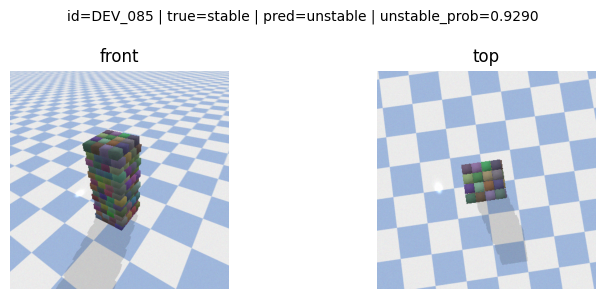

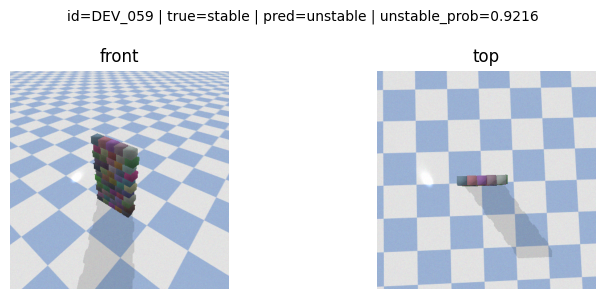

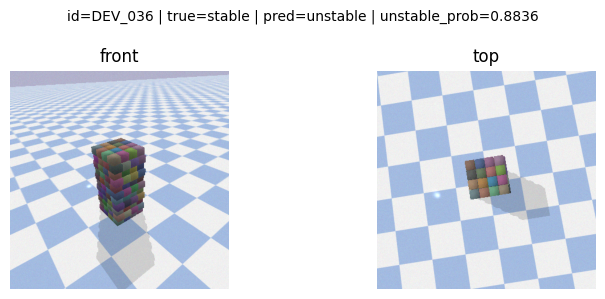

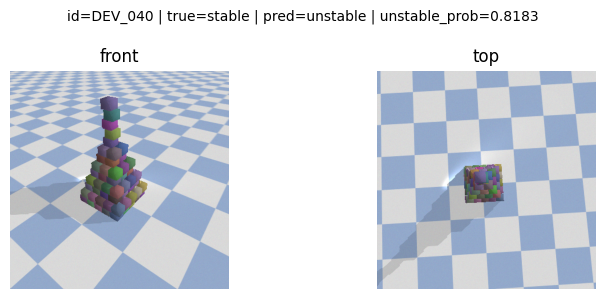

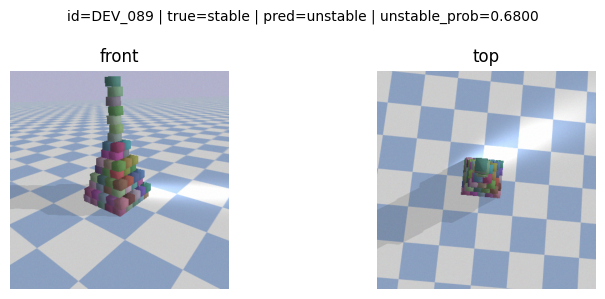

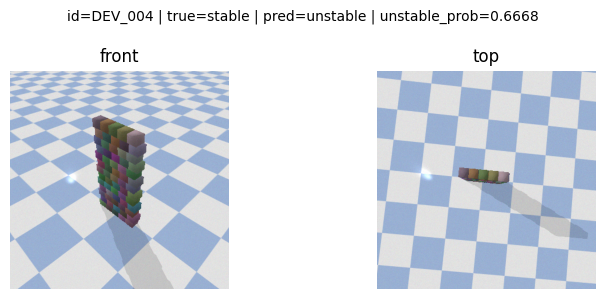

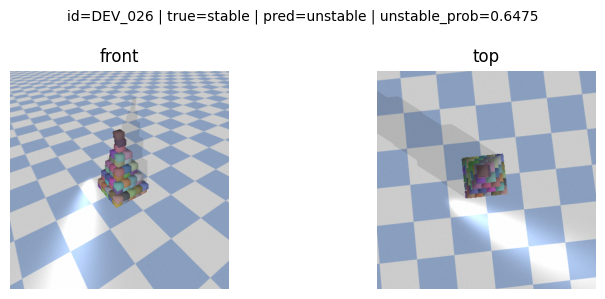

In [16]:
import matplotlib.pyplot as plt

TOP_N = 8  # 시각화할 오답 샘플 수
show_df = mistakes.head(TOP_N)

for _, row in show_df.iterrows():
    sample_id = row['id']
    front_path = DATA_DIR / 'dev' / sample_id / 'front.png'
    top_path = DATA_DIR / 'dev' / sample_id / 'top.png'

    fig, axes = plt.subplots(1, 2, figsize=(8, 3))
    axes[0].imshow(Image.open(front_path).convert('RGB'))
    axes[0].set_title('front')
    axes[0].axis('off')

    axes[1].imshow(Image.open(top_path).convert('RGB'))
    axes[1].set_title('top')
    axes[1].axis('off')

    fig.suptitle(
        f"id={sample_id} | true={row['label']} | pred={row['pred_label']} | unstable_prob={row['unstable_prob']:.4f}",
        fontsize=10
    )
    plt.tight_layout()
    plt.show()



## 5. 추론 및 제출 파일 생성

In [17]:
# 1) dev에서 TTA 조합 성능 비교
candidate_ttas = CFG['TTA_CANDIDATES']
tta_result_df = evaluate_tta_on_dev(model, val_loader, device, candidate_ttas)
display(tta_result_df)

best_tta_names = tta_result_df.iloc[0]['tta_names']
print(f"Best TTA on dev: {best_tta_names}")

# 2) best TTA로 test 추론
all_probs = predict_probs_with_tta(
    model, test_loader, device,
    tta_names=best_tta_names,
    has_labels=False,
    desc='Inference with TTA'
)

# 결과 저장
submission = pd.DataFrame({
    'id': test_df['id'],
    'unstable_prob': all_probs,
    'stable_prob': 1.0 - all_probs
})

submission.to_csv(submission_path, encoding='UTF-8-sig', index=False)
print(f'{submission_path} 저장 완료.')



Dev TTA ['none', 'hflip', 'crop95']: 100%|##########| 4/4 [00:01<00:00,  2.31it/s]


,tta_names,n_tta,val_logloss,val_acc
0,"[none, hflip, crop95]",3,0.163921,0.94
1,"[none, hflip]",2,0.165226,0.96
2,[none],1,0.192261,0.93


Best TTA on dev: ['none', 'hflip', 'crop95']


Inference with TTA: 100%|##########| 32/32 [00:10<00:00,  3.02it/s]

submission_baseline_ema.csv 저장 완료.
